     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.2 MB/s eta 0:00:00
Using device: cuda
Running 10 runs with RandomNodeSplit (80/20)


Processing...
Done!



--- Run 01 ---
Run 01 | Epoch: 001 | Loss: 2.0356 | Train Acc: 12.60% | Test Acc: 12.85%
Run 01 | Epoch: 002 | Loss: 1.8645 | Train Acc: 28.42% | Test Acc: 12.85%
Run 01 | Epoch: 003 | Loss: 1.7287 | Train Acc: 40.86% | Test Acc: 12.85%
Run 01 | Epoch: 004 | Loss: 1.6475 | Train Acc: 46.04% | Test Acc: 12.85%
Run 01 | Epoch: 005 | Loss: 1.5728 | Train Acc: 56.76% | Test Acc: 12.85%
Run 01 | Epoch: 006 | Loss: 1.5103 | Train Acc: 65.78% | Test Acc: 19.70%
Run 01 | Epoch: 007 | Loss: 1.4551 | Train Acc: 68.16% | Test Acc: 28.38%
Run 01 | Epoch: 008 | Loss: 1.4083 | Train Acc: 66.69% | Test Acc: 29.05%
Run 01 | Epoch: 009 | Loss: 1.3692 | Train Acc: 65.65% | Test Acc: 31.39%
Run 01 | Epoch: 010 | Loss: 1.3338 | Train Acc: 64.77% | Test Acc: 33.39%
Run 01 | Epoch: 011 | Loss: 1.2851 | Train Acc: 65.48% | Test Acc: 34.56%
Run 01 | Epoch: 012 | Loss: 1.2528 | Train Acc: 64.77% | Test Acc: 36.23%
Run 01 | Epoch: 013 | Loss: 1.2185 | Train Acc: 63.65% | Test Acc: 36.56%
Run 01 | Epoch: 014 | 

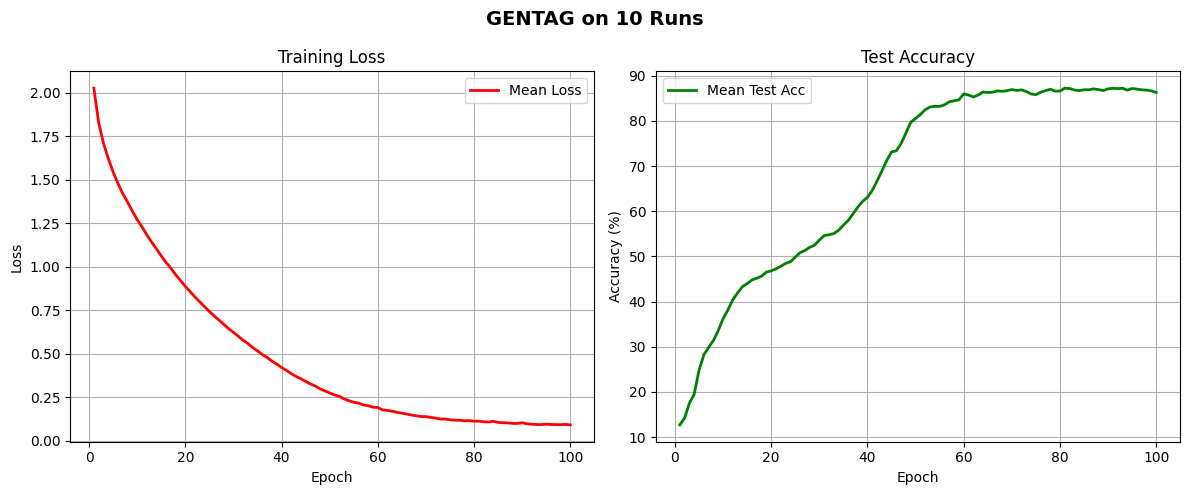

In [1]:
! pip install torch_geometric
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch_geometric.datasets import CitationFull
from torch_geometric.transforms import NormalizeFeatures, RandomNodeSplit
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.inits import zeros
from torch_geometric.typing import Adj, OptTensor, SparseTensor
from torch_geometric.utils import spmm
import torch.nn.functional as F
from torch.nn import BatchNorm1d, Dropout, InstanceNorm1d, LayerNorm, ReLU, Sequential
from typing import List, Optional
import random

# =============================================
# Device Setup + Seed
# =============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =============================================
# Helper Function
# =============================================
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
    plt.figure(figsize=(10, 10))
    plt.xticks([])
    plt.yticks([])
    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

# =============================================
# MLP
# =============================================
class MLP(Sequential):
    def __init__(self, channels: List[int], norm: Optional[str] = None, bias: bool = True, dropout: float = 0.):
        m = []
        for i in range(1, len(channels)):
            m.append(Linear(channels[i - 1], channels[i], bias=bias))
            if i < len(channels) - 1:
                if norm == 'batch':
                    m.append(BatchNorm1d(channels[i], affine=True))
                elif norm == 'layer':
                    m.append(LayerNorm(channels[i], elementwise_affine=True))
                elif norm == 'instance':
                    m.append(InstanceNorm1d(channels[i], affine=False))
                m.append(ReLU())
                m.append(Dropout(dropout))
        super().__init__(*m)

# =============================================
# TAGConv1
# =============================================
class TAGConv1(MessagePassing):
    def __init__(self, in_channels: int, out_channels: int, K: int = 9, bias: bool = True, normalize: bool = True, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.K = K
        norm: str = 'batch'
        num_layers: int = 2
        expansion: int = 2
        eps: float = 1e-7
        self.normalize = normalize
        self.lins = torch.nn.ModuleList([
            Linear(in_channels, out_channels, bias=False) for _ in range(K + 1)
        ])
        if bias:
            self.bias = torch.nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter('bias', None)

        channels = [out_channels]
        for _ in range(num_layers - 1):
            channels.append(out_channels * expansion)
        channels.append(out_channels)
        self.mlp = MLP(channels, norm=norm, bias=bias)
        self.eps = eps
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        for lin in self.lins:
            lin.reset_parameters()
        zeros(self.bias)

    def forward(self, x, edge_index, edge_weight=None):
        if self.normalize:
            if isinstance(edge_index, torch.Tensor):
                edge_index, edge_weight = gcn_norm(
                    edge_index, edge_weight, x.size(self.node_dim),
                    improved=False, add_self_loops=False,
                    flow=self.flow, dtype=x.dtype
                )
            elif isinstance(edge_index, SparseTensor):
                edge_index = gcn_norm(
                    edge_index, edge_weight, x.size(self.node_dim),
                    add_self_loops=False, flow=self.flow, dtype=x.dtype
                )

        out = self.lins[0](x)
        for lin in self.lins[1:]:
            x = self.propagate(edge_index, x=x, edge_weight=edge_weight, size=None)
            out = out + lin(x)

        if self.bias is not None:
            out = out + self.bias
        return self.mlp(out)

    def message(self, x_j, edge_weight):
        msg = x_j if edge_weight is None else edge_weight.view(-1, 1) * x_j
        return msg.relu() + self.eps

    def message_and_aggregate(self, adj_t, x):
        return spmm(adj_t, x, reduce=self.aggr)

    def __repr__(self):
        return f'{self.__class__.__name__}({self.in_channels}, {self.out_channels}, K={self.K})'

# =============================================
# GENTAG Model
# =============================================
class GENTAG(torch.nn.Module):
    def __init__(self, hidden_channels, num_features, num_classes):
        super().__init__()
        self.conv1 = TAGConv1(num_features, hidden_channels)
        self.conv2 = TAGConv1(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# =============================================
# Train Function
# =============================================
def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    train_correct = pred[data.train_mask] == data.y[data.train_mask]
    train_acc = int(train_correct.sum()) / int(data.train_mask.sum())

    return loss.item(), train_acc

# =============================================
# Test Function
# =============================================
def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

# =============================================
# MAIN: 10 Runs with RandomNodeSplit
# =============================================
root       = os.getcwd()
num_runs   = 10
num_epochs = 100
best_accuracies = []
all_runs_metrics = []

print("=" * 60)
print(f"Running {num_runs} runs with RandomNodeSplit (80/20)")
print("=" * 60)

for run in range(num_runs):

    # Fresh dataset + new random split each run
    dataset = CitationFull(root, name="Cora_ML", transform=NormalizeFeatures())
    data = dataset[0]
    splitter = RandomNodeSplit(split="train_rest", num_val=0, num_test=0.2)
    data = splitter(data)
    data = data.to(device)                          # ← CUDA

    # Fresh model each run
    torch.manual_seed(run)
    np.random.seed(run)
    random.seed(run)
    model = GENTAG(
        hidden_channels=16,
        num_features=dataset.num_features,
        num_classes=dataset.num_classes
    ).to(device)                                    # ← CUDA

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    best_acc = 0.0
    epoch_losses = []
    epoch_train_accs = []
    epoch_test_accs = []

    print(f"\n--- Run {run+1:02d} ---")

    for epoch in range(1, num_epochs + 1):
        loss, train_acc = train(model, data, optimizer, criterion)
        test_acc = test(model, data)

        epoch_losses.append(loss)
        epoch_train_accs.append(train_acc * 100)
        epoch_test_accs.append(test_acc * 100)

        if test_acc > best_acc:
            best_acc = test_acc

        print(f'Run {run+1:02d} | Epoch: {epoch:03d} | Loss: {loss:.4f} | '
              f'Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

    best_accuracies.append(best_acc)
    all_runs_metrics.append({
        'losses':     epoch_losses,
        'train_accs': epoch_train_accs,
        'test_accs':  epoch_test_accs
    })
    print(f'>>> Run {run+1:02d} Best Test Accuracy: {best_acc*100:.2f}%')

# =============================================
# Final Result
# =============================================
mean_acc = np.mean(best_accuracies)
std_acc  = np.std(best_accuracies)

print()
print("=" * 60)
print(f"  Final Result over {num_runs} runs:")
print(f"  Mean Accuracy : {mean_acc*100:.2f}%")
print(f"  Std Deviation : {std_acc*100:.2f}%")
print(f"  Report as     : {mean_acc*100:.2f} ± {std_acc*100:.2f}%")
print("=" * 60)

# =============================================
# Plot — Loss + Test Accuracy (Paper Quality)
# =============================================
epochs = range(1, num_epochs + 1)

all_test_accs = np.array([m['test_accs'] for m in all_runs_metrics])
all_losses    = np.array([m['losses']    for m in all_runs_metrics])

mean_test = np.mean(all_test_accs, axis=0)
mean_loss = np.mean(all_losses,    axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GENTAG on 10 Runs', fontsize=14, fontweight='bold')

# Loss Curve
axes[0].plot(epochs, mean_loss, color='red', linewidth=2, label='Mean Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Test Accuracy Curve
axes[1].plot(epochs, mean_test, color='green', linewidth=2, label='Mean Test Acc')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('gentag_img', dpi=300, bbox_inches='tight')
plt.show()


Using device: cuda
Running 10 runs with RandomNodeSplit (80/20)


Processing...
Done!



--- Run 01 ---
Run 01 | Epoch: 001 | Loss: 2.3695 | Train Acc: 9.94% | Test Acc: 15.85%
Run 01 | Epoch: 002 | Loss: 2.1119 | Train Acc: 31.86% | Test Acc: 16.91%
Run 01 | Epoch: 003 | Loss: 1.9704 | Train Acc: 45.06% | Test Acc: 17.09%
Run 01 | Epoch: 004 | Loss: 1.8593 | Train Acc: 54.93% | Test Acc: 17.13%
Run 01 | Epoch: 005 | Loss: 1.7704 | Train Acc: 57.68% | Test Acc: 17.09%
Run 01 | Epoch: 006 | Loss: 1.6748 | Train Acc: 63.09% | Test Acc: 18.25%
Run 01 | Epoch: 007 | Loss: 1.5863 | Train Acc: 64.71% | Test Acc: 20.29%
Run 01 | Epoch: 008 | Loss: 1.5207 | Train Acc: 65.63% | Test Acc: 22.18%
Run 01 | Epoch: 009 | Loss: 1.4476 | Train Acc: 66.79% | Test Acc: 21.35%
Run 01 | Epoch: 010 | Loss: 1.3782 | Train Acc: 67.99% | Test Acc: 19.42%
Run 01 | Epoch: 011 | Loss: 1.3090 | Train Acc: 67.93% | Test Acc: 19.16%
Run 01 | Epoch: 012 | Loss: 1.2407 | Train Acc: 68.91% | Test Acc: 25.60%
Run 01 | Epoch: 013 | Loss: 1.1806 | Train Acc: 69.36% | Test Acc: 40.95%
Run 01 | Epoch: 014 | L

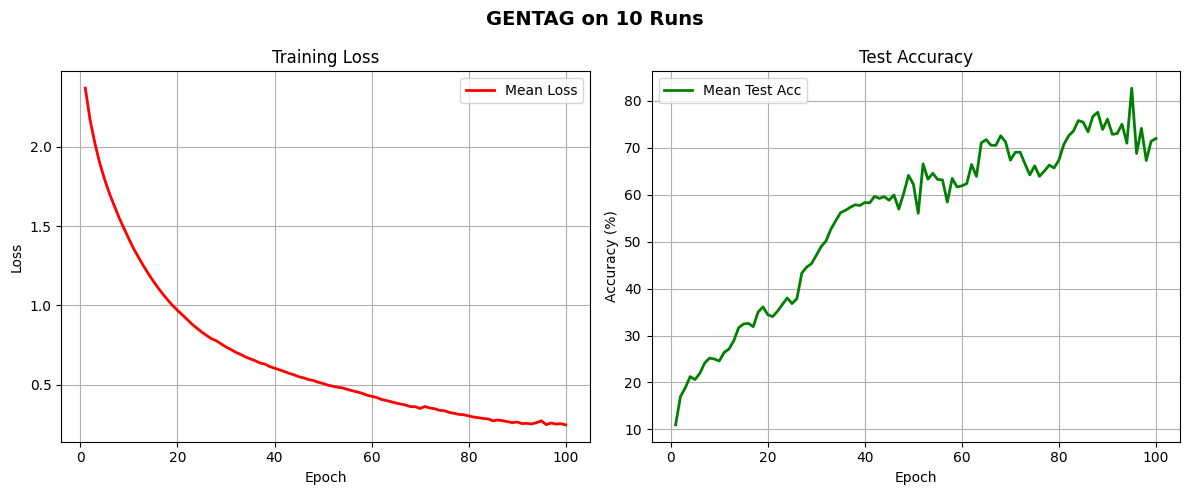

In [2]:
! pip install torch_geometric
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torch_geometric.datasets import Amazon
from torch_geometric.transforms import NormalizeFeatures, RandomNodeSplit
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.inits import zeros
from torch_geometric.typing import Adj, OptTensor, SparseTensor
from torch_geometric.utils import spmm
import torch.nn.functional as F
from torch.nn import BatchNorm1d, Dropout, InstanceNorm1d, LayerNorm, ReLU, Sequential
from typing import List, Optional
import random

# =============================================
# Device Setup + Seed
# =============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =============================================
# Helper Function
# =============================================
def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
    plt.figure(figsize=(10, 10))
    plt.xticks([])
    plt.yticks([])
    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

# =============================================
# MLP
# =============================================
class MLP(Sequential):
    def __init__(self, channels: List[int], norm: Optional[str] = None, bias: bool = True, dropout: float = 0.):
        m = []
        for i in range(1, len(channels)):
            m.append(Linear(channels[i - 1], channels[i], bias=bias))
            if i < len(channels) - 1:
                if norm == 'batch':
                    m.append(BatchNorm1d(channels[i], affine=True))
                elif norm == 'layer':
                    m.append(LayerNorm(channels[i], elementwise_affine=True))
                elif norm == 'instance':
                    m.append(InstanceNorm1d(channels[i], affine=False))
                m.append(ReLU())
                m.append(Dropout(dropout))
        super().__init__(*m)

# =============================================
# TAGConv1
# =============================================
class TAGConv1(MessagePassing):
    def __init__(self, in_channels: int, out_channels: int, K: int = 9, bias: bool = True, normalize: bool = True, **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.K = K
        norm: str = 'batch'
        num_layers: int = 2
        expansion: int = 2
        eps: float = 1e-7
        self.normalize = normalize
        self.lins = torch.nn.ModuleList([
            Linear(in_channels, out_channels, bias=False) for _ in range(K + 1)
        ])
        if bias:
            self.bias = torch.nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter('bias', None)

        channels = [out_channels]
        for _ in range(num_layers - 1):
            channels.append(out_channels * expansion)
        channels.append(out_channels)
        self.mlp = MLP(channels, norm=norm, bias=bias)
        self.eps = eps
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        for lin in self.lins:
            lin.reset_parameters()
        zeros(self.bias)

    def forward(self, x, edge_index, edge_weight=None):
        if self.normalize:
            if isinstance(edge_index, torch.Tensor):
                edge_index, edge_weight = gcn_norm(
                    edge_index, edge_weight, x.size(self.node_dim),
                    improved=False, add_self_loops=False,
                    flow=self.flow, dtype=x.dtype
                )
            elif isinstance(edge_index, SparseTensor):
                edge_index = gcn_norm(
                    edge_index, edge_weight, x.size(self.node_dim),
                    add_self_loops=False, flow=self.flow, dtype=x.dtype
                )

        out = self.lins[0](x)
        for lin in self.lins[1:]:
            x = self.propagate(edge_index, x=x, edge_weight=edge_weight, size=None)
            out = out + lin(x)

        if self.bias is not None:
            out = out + self.bias
        return self.mlp(out)

    def message(self, x_j, edge_weight):
        msg = x_j if edge_weight is None else edge_weight.view(-1, 1) * x_j
        return msg.relu() + self.eps

    def message_and_aggregate(self, adj_t, x):
        return spmm(adj_t, x, reduce=self.aggr)

    def __repr__(self):
        return f'{self.__class__.__name__}({self.in_channels}, {self.out_channels}, K={self.K})'

# =============================================
# GENTAG Model
# =============================================
class GENTAG(torch.nn.Module):
    def __init__(self, hidden_channels, num_features, num_classes):
        super().__init__()
        self.conv1 = TAGConv1(num_features, hidden_channels)
        self.conv2 = TAGConv1(hidden_channels, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# =============================================
# Train Function
# =============================================
def train(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    train_correct = pred[data.train_mask] == data.y[data.train_mask]
    train_acc = int(train_correct.sum()) / int(data.train_mask.sum())

    return loss.item(), train_acc

# =============================================
# Test Function
# =============================================
def test(model, data):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    test_correct = pred[data.test_mask] == data.y[data.test_mask]
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())
    return test_acc

# =============================================
# MAIN: 10 Runs with RandomNodeSplit
# =============================================
root       = os.getcwd()
num_runs   = 10
num_epochs = 100
best_accuracies = []
all_runs_metrics = []

print("=" * 60)
print(f"Running {num_runs} runs with RandomNodeSplit (80/20)")
print("=" * 60)

for run in range(num_runs):

    # Fresh dataset + new random split each run
    dataset = Amazon(root, name="Computers", transform=NormalizeFeatures())
    data = dataset[0]
    splitter = RandomNodeSplit(split="train_rest", num_val=0, num_test=0.2)
    data = splitter(data)
    data = data.to(device)                          # ← CUDA

    # Fresh model each run
    torch.manual_seed(run)
    np.random.seed(run)
    random.seed(run)
    model = GENTAG(
        hidden_channels=16,
        num_features=dataset.num_features,
        num_classes=dataset.num_classes
    ).to(device)                                    # ← CUDA

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    best_acc = 0.0
    epoch_losses = []
    epoch_train_accs = []
    epoch_test_accs = []

    print(f"\n--- Run {run+1:02d} ---")

    for epoch in range(1, num_epochs + 1):
        loss, train_acc = train(model, data, optimizer, criterion)
        test_acc = test(model, data)

        epoch_losses.append(loss)
        epoch_train_accs.append(train_acc * 100)
        epoch_test_accs.append(test_acc * 100)

        if test_acc > best_acc:
            best_acc = test_acc

        print(f'Run {run+1:02d} | Epoch: {epoch:03d} | Loss: {loss:.4f} | '
              f'Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%')

    best_accuracies.append(best_acc)
    all_runs_metrics.append({
        'losses':     epoch_losses,
        'train_accs': epoch_train_accs,
        'test_accs':  epoch_test_accs
    })
    print(f'>>> Run {run+1:02d} Best Test Accuracy: {best_acc*100:.2f}%')

# =============================================
# Final Result
# =============================================
mean_acc = np.mean(best_accuracies)
std_acc  = np.std(best_accuracies)

print()
print("=" * 60)
print(f"  Final Result over {num_runs} runs:")
print(f"  Mean Accuracy : {mean_acc*100:.2f}%")
print(f"  Std Deviation : {std_acc*100:.2f}%")
print(f"  Report as     : {mean_acc*100:.2f} ± {std_acc*100:.2f}%")
print("=" * 60)

# =============================================
# Plot — Loss + Test Accuracy (Paper Quality)
# =============================================
epochs = range(1, num_epochs + 1)

all_test_accs = np.array([m['test_accs'] for m in all_runs_metrics])
all_losses    = np.array([m['losses']    for m in all_runs_metrics])

mean_test = np.mean(all_test_accs, axis=0)
mean_loss = np.mean(all_losses,    axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GENTAG on 10 Runs', fontsize=14, fontweight='bold')

# Loss Curve
axes[0].plot(epochs, mean_loss, color='red', linewidth=2, label='Mean Loss')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Test Accuracy Curve
axes[1].plot(epochs, mean_test, color='green', linewidth=2, label='Mean Test Acc')
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('gentag_img', dpi=300, bbox_inches='tight')
plt.show()
